In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.preprocessing import FunctionTransformer

In [3]:
import scipy.stats as stats 

In [6]:
a=pd.read_csv('Loan payments data.csv')
a.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


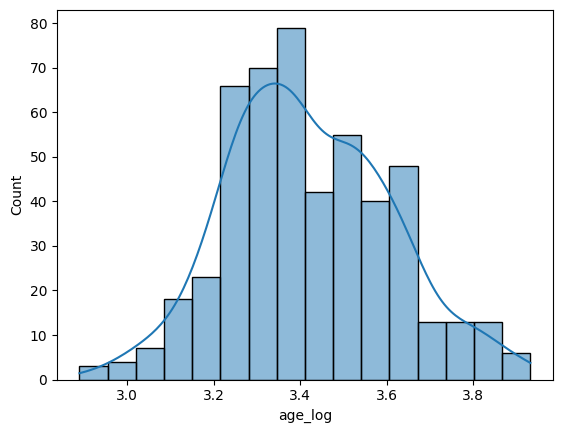

In [11]:
sns.histplot(a['age_log'], kde=True)
plt.show()

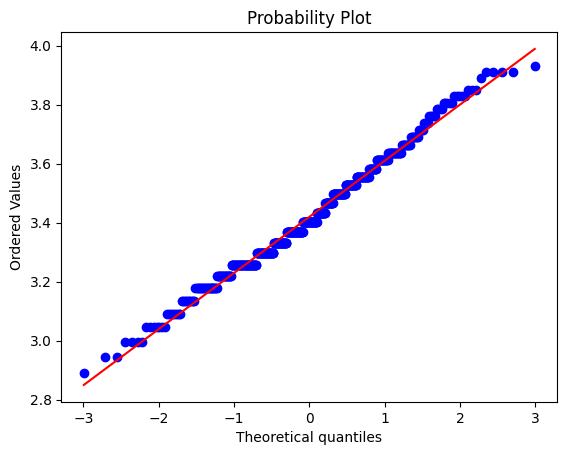

In [10]:
stats.probplot(a['age_log'], dist='norm', plot=plt)
plt.show()

In [9]:
trf = FunctionTransformer(func=np.log) #np.log1p for log(0) and log(negative)
a['age_log'] = trf.fit_transform(a['age']) 
a.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,age_log
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male,3.806662
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female,3.912023
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female,3.496508
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male,3.295837
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female,3.332205


log transform for left skewed and x**2 transform for right skewed, other transform include root and reciprocal transforms

In [16]:
stats.skew(a['age_log'])

np.float64(0.21024667461204238)

In [17]:
stats.skew(a['age'])

np.float64(0.719802515677082)

     If Skewness = 0: The distribution is perfectly symmetrical (Normal distribution).

    If Skewness is between -0.5 and 0.5: The distribution is approximately symmetric. It is generally considered not skewed enough to worry about for most statistical tests.

    If Skewness is between -1 and -0.5 (or 0.5 and 1): The distribution is moderately skewed.

    If Skewness is less than -1 (strong negative) or greater than +1 (strong positive): The distribution is highly skewed.

In [18]:
print(a['age'].mean(), a['age'].median())

31.116 30.0


In [19]:
print(a['age_log'].mean(), a['age_log'].median())

3.4193972100998424 3.4011973816621555


## Feature Selection

In [6]:
from mlxtend.feature_selection import SequentialFeatureSelector 
from sklearn.linear_model import LinearRegression

In [4]:
!python -m pip install mlxtend


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
df = pd.read_csv('diabetes.csv')
df.head()   

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
df.shape

(768, 9)

In [10]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [11]:
lr=LinearRegression()

In [61]:
fs = SequentialFeatureSelector(lr, k_features=3, forward=False) #backward=False for backward selection
fs.fit(x, y)

,estimator,LinearRegression()
,k_features,"(3, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'r2'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [62]:
fs.feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [63]:
fs.k_feature_names_

('Pregnancies', 'Glucose', 'BMI')

In [64]:
fs.k_score_

np.float64(0.2664316170229693)

## Test Train Split

In [65]:
from sklearn.model_selection import train_test_split

In [68]:
df.shape

(768, 9)


| Dataset Size | Recommended Test Size | Recommended Technique |
| :--- | :--- | :--- |
| **Very Large (>100k)** | **10% - 15%** | Simple Hold-out |
| **Large (10k - 100k)** | **15% - 20%** | Simple Hold-out |
| **Medium (1k - 10k)** | **20% - 25%** | Simple Hold-out |
| **Small (< 1k)** | **20% - 30%** | Hold-out (if representative) |
| **Very Small (< 100)** | **N/A** | **K-Fold Cross-Validation** |
| **Time Series** | Last 20-30% of Period | Chronological Split |
| **Imbalanced Data** | 20% - 40% (stratified) | Stratified Split |

In [66]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [69]:
x_test.shape , x_train.shape

((192, 8), (576, 8))